In [1]:
import os
import cv2
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
IMAGE_PATH = "/content/drive/MyDrive/RIM-ONE_DL_images/RIM-ONE_DL_images"
SEG_PATH = "/content/drive/MyDrive/RIM-ONE_DL_reference_segmentations/RIM-ONE_DL_reference_segmentations"
print(os.path.exists(IMAGE_PATH))
print(os.path.exists(SEG_PATH))

True
True


In [4]:
image_index = {}
for root, dirs, files in os.walk(IMAGE_PATH):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            image_id = os.path.splitext(file)[0]
            if image_id not in image_index:
                image_index[image_id] = os.path.join(root, file)
print("Images found:", len(image_index))

Images found: 485


In [5]:
segmentation_pairs = []
for class_name in ["normal", "glaucoma"]:
    folder = os.path.join(SEG_PATH, class_name)
    for file in os.listdir(folder):
        if file.endswith("-Disc-T.png"):

            seg_id = file.replace("-Disc-T.png", "")

            disc_path = os.path.join(folder, file)

            cup_path = os.path.join(
                folder,
                seg_id + "-Cup-T.png"
            )
            if os.path.exists(cup_path):
                segmentation_pairs.append({
                    "seg_id": seg_id,
                    "class": class_name,
                    "disc_path": disc_path,
                    "cup_path": cup_path
                })

print("Segmentation pairs:", len(segmentation_pairs))

Segmentation pairs: 485


In [6]:
segmentation_pairs = []

for class_name in ["normal", "glaucoma"]:

    folder = os.path.join(SEG_PATH, class_name)

    for file in os.listdir(folder):

        if file.endswith("-Disc-T.png"):

            seg_id = file.replace("-Disc-T.png", "")

            disc_path = os.path.join(folder, file)

            cup_path = os.path.join(
                folder,
                seg_id + "-Cup-T.png"
            )

            if os.path.exists(cup_path):

                segmentation_pairs.append({
                    "seg_id": seg_id,
                    "class": class_name,
                    "disc_path": disc_path,
                    "cup_path": cup_path
                })

print("Segmentation pairs:", len(segmentation_pairs))

Segmentation pairs: 485


In [7]:
matched_pairs = []

for item in segmentation_pairs:

    seg_id = item["seg_id"]

    if seg_id.endswith("-1"):
        image_id = seg_id[:-2]
    else:
        image_id = seg_id

    if image_id in image_index:

        matched_pairs.append({
            "image_id": image_id,
            "class": item["class"],
            "image_path": image_index[image_id],
            "disc_path": item["disc_path"],
            "cup_path": item["cup_path"]
        })

print("Matched:", len(matched_pairs))

Matched: 485


In [8]:
matched_pairs = []

for item in segmentation_pairs:

    seg_id = item["seg_id"]

    if seg_id.endswith("-1"):
        image_id = seg_id[:-2]
    else:
        image_id = seg_id

    if image_id in image_index:

        matched_pairs.append({
            "image_id": image_id,
            "class": item["class"],
            "image_path": image_index[image_id],
            "disc_path": item["disc_path"],
            "cup_path": item["cup_path"]
        })

print("Matched:", len(matched_pairs))

Matched: 485


In [9]:
sample = matched_pairs[0]

print(sample)

{'image_id': 'r2_Im038', 'class': 'normal', 'image_path': '/content/drive/MyDrive/RIM-ONE_DL_images/RIM-ONE_DL_images/partitioned_by_hospital/training_set/normal/r2_Im038.png', 'disc_path': '/content/drive/MyDrive/RIM-ONE_DL_reference_segmentations/RIM-ONE_DL_reference_segmentations/normal/r2_Im038-1-Disc-T.png', 'cup_path': '/content/drive/MyDrive/RIM-ONE_DL_reference_segmentations/RIM-ONE_DL_reference_segmentations/normal/r2_Im038-1-Cup-T.png'}


In [10]:
def extract_features(disc_path, cup_path):

    disc = cv2.imread(disc_path, cv2.IMREAD_GRAYSCALE)
    cup = cv2.imread(cup_path, cv2.IMREAD_GRAYSCALE)

    if disc is None or cup is None:
        return None

    disc_binary = (disc > 0).astype(np.uint8)
    cup_binary = (cup > 0).astype(np.uint8)

    disc_area = np.sum(disc_binary)
    cup_area = np.sum(cup_binary)

    if disc_area == 0 or cup_area == 0:
        return None

    disc_contours, _ = cv2.findContours(
        disc_binary * 255,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cup_contours, _ = cv2.findContours(
        cup_binary * 255,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not disc_contours or not cup_contours:
        return None

    disc_contour = max(disc_contours, key=cv2.contourArea)
    cup_contour = max(cup_contours, key=cv2.contourArea)

    disc_perimeter = cv2.arcLength(disc_contour, True)
    cup_perimeter = cv2.arcLength(cup_contour, True)

    _, _, disc_width, disc_height = cv2.boundingRect(disc_contour)
    _, _, cup_width, cup_height = cv2.boundingRect(cup_contour)

    return {
        "disc_area": disc_area,
        "cup_area": cup_area,
        "cup_disc_area_ratio": cup_area / disc_area,
        "disc_perimeter": disc_perimeter,
        "cup_perimeter": cup_perimeter,
        "disc_width": disc_width,
        "disc_height": disc_height,
        "cup_width": cup_width,
        "cup_height": cup_height,
        "cup_disc_width_ratio": cup_width / disc_width,
        "cup_disc_height_ratio": cup_height / disc_height
    }

In [11]:
features = extract_features(
    sample["disc_path"],
    sample["cup_path"]
)

print(features)

{'disc_area': np.uint64(179399), 'cup_area': np.uint64(30100), 'cup_disc_area_ratio': np.float64(0.16778242911053015), 'disc_perimeter': 1583.959580898285, 'cup_perimeter': 646.4406862258911, 'disc_width': 465, 'disc_height': 492, 'cup_width': 198, 'cup_height': 194, 'cup_disc_width_ratio': 0.4258064516129032, 'cup_disc_height_ratio': 0.3943089430894309}


In [12]:
rows = []

for item in matched_pairs:

    features = extract_features(
        item["disc_path"],
        item["cup_path"]
    )

    if features is None:
        continue

    features["image_id"] = item["image_id"]
    features["class"] = item["class"]

    rows.append(features)

print("Rows created:", len(rows))

Rows created: 485


In [13]:
df = pd.DataFrame(rows)

print(df.shape)
display(df.head())

(485, 13)


,disc_area,cup_area,cup_disc_area_ratio,disc_perimeter,cup_perimeter,disc_width,disc_height,cup_width,cup_height,cup_disc_width_ratio,cup_disc_height_ratio,image_id,class
0,179399,30100,0.167782,1583.959581,646.440686,465,492,198,194,0.425806,0.394309,r2_Im038,normal
1,139202,16487,0.118439,1401.994069,477.002089,375,467,146,144,0.389333,0.308351,r2_Im092,normal
2,146567,8882,0.060600,1430.420478,358.534052,421,445,91,126,0.216152,0.283146,r2_Im070,normal
3,53820,10800,0.200669,876.205185,389.889392,250,285,113,127,0.452000,0.445614,r1_Im143,normal
4,81804,20817,0.254474,1080.714852,555.327989,293,363,135,205,0.460751,0.564738,r1_Im054,normal


In [14]:
print(df["class"].value_counts())

class
normal      313
glaucoma    172
Name: count, dtype: int64


In [15]:
print(df.isnull().sum())

disc_area                0
cup_area                 0
cup_disc_area_ratio      0
disc_perimeter           0
cup_perimeter            0
disc_width               0
disc_height              0
cup_width                0
cup_height               0
cup_disc_width_ratio     0
cup_disc_height_ratio    0
image_id                 0
class                    0
dtype: int64


In [16]:
CSV_PATH = "/content/drive/MyDrive/glaucoma_handcrafted_features.csv"

df.to_csv(CSV_PATH, index=False)

print("Saved:", CSV_PATH)

Saved: /content/drive/MyDrive/glaucoma_handcrafted_features.csv


In [17]:
df_check = pd.read_csv(CSV_PATH)

print(df_check.shape)
display(df_check.head())

(485, 13)


,disc_area,cup_area,cup_disc_area_ratio,disc_perimeter,cup_perimeter,disc_width,disc_height,cup_width,cup_height,cup_disc_width_ratio,cup_disc_height_ratio,image_id,class
0,179399,30100,0.167782,1583.959581,646.440686,465,492,198,194,0.425806,0.394309,r2_Im038,normal
1,139202,16487,0.118439,1401.994069,477.002089,375,467,146,144,0.389333,0.308351,r2_Im092,normal
2,146567,8882,0.060600,1430.420478,358.534052,421,445,91,126,0.216152,0.283146,r2_Im070,normal
3,53820,10800,0.200669,876.205185,389.889392,250,285,113,127,0.452000,0.445614,r1_Im143,normal
4,81804,20817,0.254474,1080.714852,555.327989,293,363,135,205,0.460751,0.564738,r1_Im054,normal


In [18]:
import pandas as pd
import numpy as np

CSV_PATH = "/content/drive/MyDrive/glaucoma_handcrafted_features.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (485, 13)


,disc_area,cup_area,cup_disc_area_ratio,disc_perimeter,cup_perimeter,disc_width,disc_height,cup_width,cup_height,cup_disc_width_ratio,cup_disc_height_ratio,image_id,class
0,179399,30100,0.167782,1583.959581,646.440686,465,492,198,194,0.425806,0.394309,r2_Im038,normal
1,139202,16487,0.118439,1401.994069,477.002089,375,467,146,144,0.389333,0.308351,r2_Im092,normal
2,146567,8882,0.060600,1430.420478,358.534052,421,445,91,126,0.216152,0.283146,r2_Im070,normal
3,53820,10800,0.200669,876.205185,389.889392,250,285,113,127,0.452000,0.445614,r1_Im143,normal
4,81804,20817,0.254474,1080.714852,555.327989,293,363,135,205,0.460751,0.564738,r1_Im054,normal


In [19]:
print(df["class"].unique())
print(df["class"].value_counts())

['normal' 'glaucoma']
class
normal      313
glaucoma    172
Name: count, dtype: int64


In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

In [21]:
CSV_PATH = "/content/drive/MyDrive/glaucoma_handcrafted_features.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (485, 13)


,disc_area,cup_area,cup_disc_area_ratio,disc_perimeter,cup_perimeter,disc_width,disc_height,cup_width,cup_height,cup_disc_width_ratio,cup_disc_height_ratio,image_id,class
0,179399,30100,0.167782,1583.959581,646.440686,465,492,198,194,0.425806,0.394309,r2_Im038,normal
1,139202,16487,0.118439,1401.994069,477.002089,375,467,146,144,0.389333,0.308351,r2_Im092,normal
2,146567,8882,0.060600,1430.420478,358.534052,421,445,91,126,0.216152,0.283146,r2_Im070,normal
3,53820,10800,0.200669,876.205185,389.889392,250,285,113,127,0.452000,0.445614,r1_Im143,normal
4,81804,20817,0.254474,1080.714852,555.327989,293,363,135,205,0.460751,0.564738,r1_Im054,normal


In [22]:
print("Classes:")
print(df["class"].unique())

print("\nClass counts:")
print(df["class"].value_counts())

Classes:
['normal' 'glaucoma']

Class counts:
class
normal      313
glaucoma    172
Name: count, dtype: int64


In [23]:
feature_columns = [
    "disc_area",
    "cup_area",
    "cup_disc_area_ratio",
    "disc_perimeter",
    "cup_perimeter",
    "disc_width",
    "disc_height",
    "cup_width",
    "cup_height",
    "cup_disc_width_ratio",
    "cup_disc_height_ratio"
]

X = df[feature_columns].copy()

y = df["class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (485, 11)
y shape: (485,)


In [24]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
disc_area                0
cup_area                 0
cup_disc_area_ratio      0
disc_perimeter           0
cup_perimeter            0
disc_width               0
disc_height              0
cup_width                0
cup_height               0
cup_disc_width_ratio     0
cup_disc_height_ratio    0
dtype: int64

Missing values in y:
0


In [25]:
X = X.fillna(X.median())

print(X.isnull().sum())

disc_area                0
cup_area                 0
cup_disc_area_ratio      0
disc_perimeter           0
cup_perimeter            0
disc_width               0
disc_height              0
cup_width                0
cup_height               0
cup_disc_width_ratio     0
cup_disc_height_ratio    0
dtype: int64


In [26]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Class mapping:")

for label, number in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    print(label, "=", number)

Class mapping:
glaucoma = 0
normal = 1


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 339
Testing samples: 146


In [28]:
neigh = KNeighborsClassifier(
    n_neighbors=3
)

neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [29]:
accuracy = neigh.score(
    X_test,
    y_test
)

print("kNN Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

kNN Accuracy: 0.8287671232876712
Accuracy percentage: 82.87671232876713


In [30]:
predictions = neigh.predict(X_test)

print("Predictions:")
print(predictions)

Predictions:
[1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1
 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1
 1 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 1 1 0 0 0 1
 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 1]


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


def euclidean_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    return np.sqrt(np.sum((a - b) ** 2))

In [32]:
def bubble_sort(items):
    items = items.copy()
    n = len(items)

    for i in range(n):
        for j in range(0, n - i - 1):

            if items[j][0] > items[j + 1][0]:

                items[j], items[j + 1] = items[j + 1], items[j]

            elif items[j][0] == items[j + 1][0]:

                if items[j][1] > items[j + 1][1]:
                    items[j], items[j + 1] = items[j + 1], items[j]

    return items

In [33]:
def selection_sort(items):
    items = items.copy()
    n = len(items)

    for i in range(n):

        min_index = i

        for j in range(i + 1, n):

            if items[j][0] < items[min_index][0]:

                min_index = j

            elif items[j][0] == items[min_index][0]:

                if items[j][1] < items[min_index][1]:
                    min_index = j

        items[i], items[min_index] = items[min_index], items[i]

    return items

In [34]:
def insertion_sort(items):
    items = items.copy()

    for i in range(1, len(items)):

        current = items[i]
        j = i - 1

        while j >= 0:

            if items[j][0] > current[0]:

                items[j + 1] = items[j]
                j -= 1

            elif items[j][0] == current[0] and items[j][1] > current[1]:

                items[j + 1] = items[j]
                j -= 1

            else:
                break

        items[j + 1] = current

    return items

In [35]:
def sort_distances(items, method="bubble"):

    if method == "bubble":
        return bubble_sort(items)

    elif method == "selection":
        return selection_sort(items)

    elif method == "insertion":
        return insertion_sort(items)

    else:
        raise ValueError(
            "Invalid sorting method. "
            "Choose bubble, selection, or insertion."
        )

In [36]:
class MyKNN:

    def __init__(self, k=3, sorting_method="bubble", weighted=False):
        self.k = k
        self.sorting_method = sorting_method
        self.weighted = weighted

        self.X_train = None
        self.y_train = None

    def fit(self, X, y):

        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)

        return self

    def _predict_one(self, x):

        distances = []

        for i in range(len(self.X_train)):

            distance = euclidean_distance(
                x,
                self.X_train[i]
            )

            distances.append(
                (distance, i, self.y_train[i])
            )

        sorted_distances = sort_distances(
            distances,
            self.sorting_method
        )

        neighbors = sorted_distances[:self.k]

        if self.weighted:
            return self._weighted_vote(neighbors)

        return self._majority_vote(neighbors)

    def _majority_vote(self, neighbors):

        votes = {}

        for distance, index, label in neighbors:

            label = int(label)

            if label not in votes:
                votes[label] = 0

            votes[label] += 1

        max_votes = max(votes.values())

        candidates = [
            label
            for label, count in votes.items()
            if count == max_votes
        ]

        if len(candidates) == 1:
            return candidates[0]

        # Tie-breaking:
        # choose the class appearing in the closest neighbour
        for distance, index, label in neighbors:

            if int(label) in candidates:
                return int(label)

    def _weighted_vote(self, neighbors):

        weights = {}

        for distance, index, label in neighbors:

            label = int(label)

            if label not in weights:
                weights[label] = 0.0

            if distance == 0:
                weight = 1e12
            else:
                weight = 1.0 / distance

            weights[label] += weight

        max_weight = max(weights.values())

        candidates = [
            label
            for label, weight in weights.items()
            if np.isclose(weight, max_weight)
        ]

        if len(candidates) == 1:
            return candidates[0]

        # Tie-breaking using closest neighbour
        for distance, index, label in neighbors:

            if int(label) in candidates:
                return int(label)

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        predictions = []

        for x in X:

            prediction = self._predict_one(x)

            predictions.append(prediction)

        return np.array(predictions)

    def score(self, X, y):

        predictions = self.predict(X)
        y = np.asarray(y)

        return np.mean(predictions == y)

In [37]:
my_knn = MyKNN(
    k=3,
    sorting_method="bubble",
    weighted=False
)

my_knn.fit(X_train, y_train)

my_predictions = my_knn.predict(X_test)

my_accuracy = my_knn.score(
    X_test,
    y_test
)

print("Own kNN Accuracy:", my_accuracy)
print("Own kNN Accuracy (%):", my_accuracy * 100)

Own kNN Accuracy: 0.8287671232876712
Own kNN Accuracy (%): 82.87671232876713


In [38]:
sorting_methods = [
    "bubble",
    "selection",
    "insertion"
]

for method in sorting_methods:

    model = MyKNN(
        k=3,
        sorting_method=method,
        weighted=False
    )

    model.fit(X_train, y_train)

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        method,
        "Accuracy:",
        round(accuracy * 100, 2),
        "%"
    )

bubble Accuracy: 82.88 %
selection Accuracy: 82.88 %
insertion Accuracy: 82.88 %


In [39]:
k_values = [1, 3, 5, 7, 9, 11]

own_accuracies = []
sklearn_accuracies = []

for k in k_values:

    # -------------------------
    # Own kNN
    # -------------------------

    own_model = MyKNN(
        k=k,
        sorting_method="bubble",
        weighted=False
    )

    own_model.fit(X_train, y_train)

    own_accuracy = own_model.score(
        X_test,
        y_test
    )

    own_accuracies.append(own_accuracy)


    # -------------------------
    # sklearn kNN
    # -------------------------

    sklearn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    sklearn_model.fit(
        X_train,
        y_train
    )

    sklearn_accuracy = sklearn_model.score(
        X_test,
        y_test
    )

    sklearn_accuracies.append(
        sklearn_accuracy
    )


    print(
        "k =", k,
        "| Own kNN =",
        round(own_accuracy * 100, 2),
        "%",
        "| sklearn =",
        round(sklearn_accuracy * 100, 2),
        "%"
    )

k = 1 | Own kNN = 74.66 % | sklearn = 74.66 %
k = 3 | Own kNN = 82.88 % | sklearn = 82.88 %
k = 5 | Own kNN = 86.3 % | sklearn = 86.3 %
k = 7 | Own kNN = 84.25 % | sklearn = 84.25 %
k = 9 | Own kNN = 84.93 % | sklearn = 84.93 %
k = 11 | Own kNN = 81.51 % | sklearn = 81.51 %


In [40]:
comparison_a8 = pd.DataFrame({
    "k": k_values,
    "Own kNN Accuracy": own_accuracies,
    "Sklearn kNN Accuracy": sklearn_accuracies
})

comparison_a8["Own kNN (%)"] = (
    comparison_a8["Own kNN Accuracy"] * 100
)

comparison_a8["Sklearn (%)"] = (
    comparison_a8["Sklearn kNN Accuracy"] * 100
)

display(comparison_a8)

,k,Own kNN Accuracy,Sklearn kNN Accuracy,Own kNN (%),Sklearn (%)
0,1,0.746575,0.746575,74.657534,74.657534
1,3,0.828767,0.828767,82.876712,82.876712
2,5,0.863014,0.863014,86.301370,86.301370
3,7,0.842466,0.842466,84.246575,84.246575
4,9,0.849315,0.849315,84.931507,84.931507
5,11,0.815068,0.815068,81.506849,81.506849


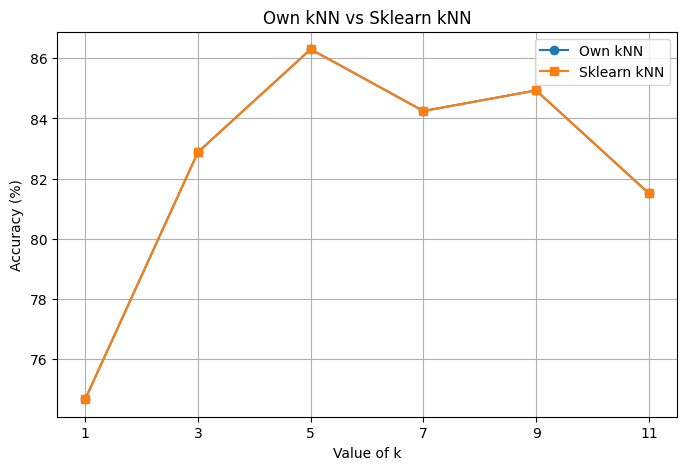

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    comparison_a8["Own kNN (%)"],
    marker="o",
    label="Own kNN"
)

plt.plot(
    k_values,
    comparison_a8["Sklearn (%)"],
    marker="s",
    label="Sklearn kNN"
)

plt.xlabel("Value of k")
plt.ylabel("Accuracy (%)")
plt.title("Own kNN vs Sklearn kNN")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

In [42]:
weighted_accuracies = []

for k in k_values:

    weighted_model = MyKNN(
        k=k,
        sorting_method="bubble",
        weighted=True
    )

    weighted_model.fit(
        X_train,
        y_train
    )

    accuracy = weighted_model.score(
        X_test,
        y_test
    )

    weighted_accuracies.append(
        accuracy
    )

    print(
        "k =", k,
        "| Weighted kNN =",
        round(accuracy * 100, 2),
        "%"
    )

k = 1 | Weighted kNN = 74.66 %
k = 3 | Weighted kNN = 77.4 %
k = 5 | Weighted kNN = 81.51 %
k = 7 | Weighted kNN = 84.25 %
k = 9 | Weighted kNN = 84.93 %
k = 11 | Weighted kNN = 82.88 %


In [43]:
comparison_a9 = pd.DataFrame({
    "k": k_values,

    "Normal kNN (%)":
        np.array(own_accuracies) * 100,

    "Weighted kNN (%)":
        np.array(weighted_accuracies) * 100,

    "Sklearn kNN (%)":
        np.array(sklearn_accuracies) * 100
})

display(comparison_a9)

,k,Normal kNN (%),Weighted kNN (%),Sklearn kNN (%)
0,1,74.657534,74.657534,74.657534
1,3,82.876712,77.397260,82.876712
2,5,86.301370,81.506849,86.301370
3,7,84.246575,84.246575,84.246575
4,9,84.931507,84.931507,84.931507
5,11,81.506849,82.876712,81.506849


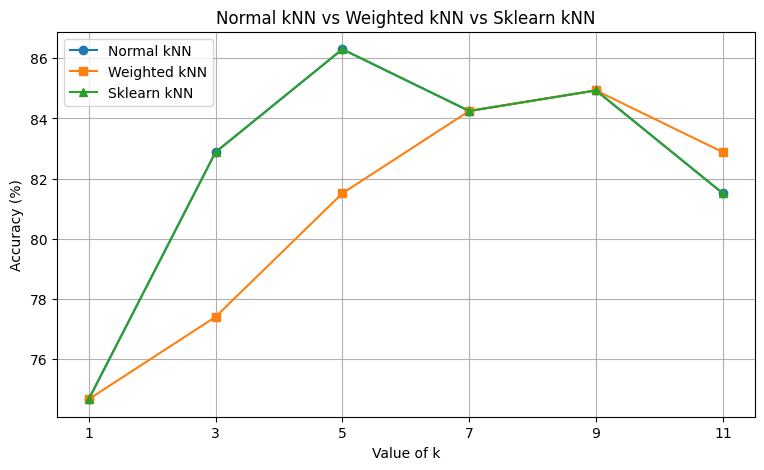

In [44]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    comparison_a9["Normal kNN (%)"],
    marker="o",
    label="Normal kNN"
)

plt.plot(
    k_values,
    comparison_a9["Weighted kNN (%)"],
    marker="s",
    label="Weighted kNN"
)

plt.plot(
    k_values,
    comparison_a9["Sklearn kNN (%)"],
    marker="^",
    label="Sklearn kNN"
)

plt.xlabel("Value of k")
plt.ylabel("Accuracy (%)")
plt.title("Normal kNN vs Weighted kNN vs Sklearn kNN")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()